In [1]:
# toggle between "notebook" and "inline", if graphs are not directly displayes
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

import yaml
import sys
# import "local" version of Orb functions
import os
sys.path.append("/homes/sjanssen/Git/jlab/orb2/plotting")

import itertools
import skbio
import edlib
from compile_data_orb import *
from plot_include_orb import *
from ggmap.snippets import *
from ggmap.settings import *

# little helper function to export plt figures as PDF
def savefig(fig, name, skip=False):
    fp_output = 'GeneratedFigures_refactor'
    if skip is False:
        os.makedirs(fp_output, exist_ok=True)
        fig.savefig('%s/%s.pdf' % (fp_output, name), bbox_inches="tight")

ggmap is custome code from Stefan Janssen, download at https://github.com/sjanssen2/ggmap, using commit '66c32398d9f428d62dd80154591743a7bab87ede'
Reading settings file '/homes/sjanssen/.ggmaprc'


In [3]:
# point to actual paths in our file system
verbose = True
with open("/homes/sjanssen/Git/jlab/orb2/plotting/style.yaml", "r") as f:
    orb_settings = yaml.safe_load(f)

fp_orb_basedir = '/vol/jlab/tlin/all_project/nf_results/orb/overlap_fix'
fp_ogtruth_basedir = '/vol/jlab/tlin/deliveries/jun_envs_deseq2_edger'
fp_marbel_basedir = '/vol/jlab/tlin/marbel_benchmarking_integration/benchmarking_sets_all_sparse_fixed_libsize'
marbel_sequence_file = "/homes/sjanssen/Git/jlab/marbel/src/marbel/data/deduplicated_pangenome_EDGAR_Microbiome_JLAB2.fas.bgz.bio_index"
fp_caviar_basedir = '/vol/jlab/tlin/all_project/nf_results/assembler_benchmark_pipeline/benchmarking_sets_all_sparse_fixed_libsize/assembler'
fp_quast_basedir = '/vol/jlab/tlin/marbel_benchmarking_integration/rnaquast_all_sparse'
fp_detonate_basedir = '/vol/jlab/tlin/marbel_benchmarking_integration/detonate_all_sparse_merged/'
fp_genomes = '/vol/jlab/tlin/all_project/in_silico_dataset/reference_information/references/ncbi_dataset/data/'

## Resulting contigs are largely faithful assemblies but often not maximally extended and many transcripts remain undiscovered.
### Figure 2

Compiling data for contig recovery plot: 100%|██████████| 6/6 [00:00<00:00, 44.79it/s]
Drawing panels for contig recovery plot: 6it [00:00,  6.85it/s]


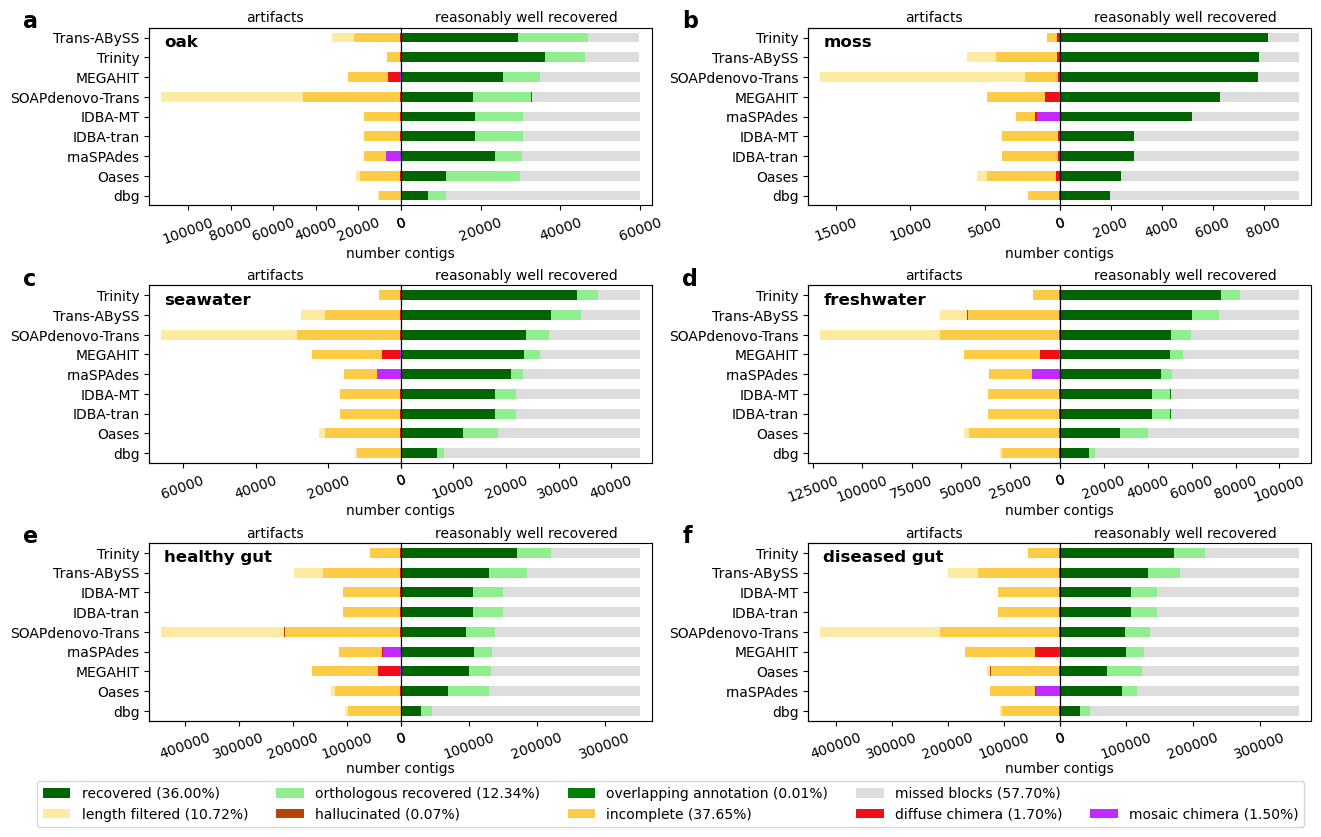

In [4]:
fig = plot_recovery(fp_orb_basedir, orb_settings, num_columns=2, verbose=verbose, detail_view=False, report_percent=True)
savefig(fig, "figure_2-recovery")

In [5]:
# get figure data
data_recovery = getdata_recovery(fp_orb_basedir, orb_settings, detail_view=False, verbose=True).reset_index().rename(columns={'index': 'assembler', 'recovery_rank': 'rank_recovery'}).set_index(['environment', 'assembler'])
data_recovery.head()

Compiling data for contig recovery plot: 100%|██████████| 6/6 [00:00<00:00, 56.20it/s]


mosaic chimera  diffuse chimera  incomplete  \
environment assembler                                                
oak         dbg                   2.0             30.0     10397.0   
            Oases                19.0            270.0     18953.0   
            rnaSPAdes          6730.0            169.0     10399.0   
            IDBA-tran            35.0            113.0     17255.0   
            IDBA-MT              35.0            113.0     17255.0   

                       hallucinated  length filtered  recovered  \
environment assembler                                             
oak         dbg                 1.0            444.0     6738.0   
            Oases              14.0           1555.0    11315.0   
            rnaSPAdes           1.0              0.0    23674.0   
            IDBA-tran           0.0              0.0    18553.0   
            IDBA-MT             0.0              0.0    18553.0   

                       orthologous recovered  overlapping annotation  \
environment assembler                                                  
oak         dbg                       4701.0                     2.0   
            Oases                    18483.0                     7.0   
            rnaSPAdes                 6651.0                     8.0   
            IDBA-tran                12072.0                    13.0   
            IDBA-MT                  12072.0                    13.0   

                       missed blocks  rank_recovery  
environment assembler                                
oak         dbg              48598.0              9  
            Oases            30226.0              8  
            rnaSPAdes        29523.0              7  
            IDBA-tran        29285.0              6  
            IDBA-MT          29285.0              5

### Notably, Oases consistently reconstructs a higher amount of contigs classified as orthologous recovered than all other assemblers (p=0.002, two-sided Mann-Whitney test).

In [6]:
# ratio of orthologous recovered by all "reasonable well recovered"
or_ratios = data_recovery['orthologous recovered'] / data_recovery[['orthologous recovered', 'recovered', 'overlapping annotation']].sum(axis=1)
mannwhitneyu(
    or_ratios[or_ratios.index.get_level_values(1) == 'Oases'].values,
    or_ratios[or_ratios.index.get_level_values(1) != 'Oases'].values)

MannwhitneyuResult(statistic=231.0, pvalue=0.017008386841365797)

### Oases seemingly makes more use of functional redundancy, relative to otherwise highly performing programs Trinity or MEGAHIT.

In [7]:
or_ratios.reset_index().groupby('assembler')[0].mean().loc[['Oases', 'Trinity', 'MEGAHIT']]

assembler
Oases      0.365410
Trinity    0.144675
MEGAHIT    0.155434
Name: 0, dtype: float64

### Overlap Annotations
#### Of all ~2.5 million CDS annotations in the training genomes, 1.6% actually pairwise overlap by at least 16bp.

In [8]:
minOverlap = 16

num_pair_overlaps = dict()
marbel_cds = pd.read_parquet(os.path.join(os.path.dirname(marbel_sequence_file), "cds_genomic_locations.parquet"))
for replicon, g in marbel_cds.groupby('chr'):
    assert (g['genomic_start'] <= g['genomic_end']).all(), 'not all genomic_start positions are smaller or equal than genomic_end positions!'
    # sort by replicon position
    g = g.sort_values(by='genomic_start')
    # combine end of CDS i with start of CDS i+1
    # we ignore overlaps of more than two CDS!
    pairs = list(zip(g['cds'].values,
                     g['cds'].values[1:], 
                     (g['genomic_end'] - minOverlap + 1).values, 
                     g['genomic_start'].values[1:]))
    num_pair_overlaps[replicon] = [tuple(sorted([idxI, idxIp1])) for (idxI, idxIp1, endI, startIp1) in pairs if startIp1 <= endI]
val = sum(map(len, num_pair_overlaps.values()))
val_num_overlappedCDS = len({x for ol in num_pair_overlaps.values() for pair in ol for x in list(pair)})
print("Number pairwise overlapps of two CDS annotations in training data each:", val)
print("Number CDS annotations that overlap in training data:", val_num_overlappedCDS)
print("  = %.2f%% of all (%i) CDS annotations" % ((val_num_overlappedCDS / marbel_cds.shape[0]) * 100, marbel_cds.shape[0]))

Number pairwise overlapps of two CDS annotations in training data each: 39037
Number CDS annotations that overlap in training data: 76963
  = 3.10% of all (2480203) CDS annotations


#### As Marble enriches for orthologous groups, i.e. is biased against single, unrelated CDS, a four times smaller ratio of overlapping blocks occur in our six environments, totalling to 3,815 overlapping blocks or 0.4%.

In [9]:
res = []
for env in get_environments(fp_orb_basedir, orb_settings):
    num_blocks = None
    with open(os.path.join(fp_marbel_basedir, env + '_microbiome', 'summary', 'blocks.bed'), 'r') as f:
        num_blocks = len(f.readlines())
    ob = pd.read_csv(os.path.join(fp_marbel_basedir, env + '_microbiome', 'summary', 'overlap_blocks.tsv'), sep="\t")
    num_overlapblocks = ob['overlap_blocks'].apply(lambda x: len(x.split(','))).sum()
    res.append({'environment': env, 'overlap_blocks': num_overlapblocks, 'blocks': num_blocks})

val_ob = sum([e['overlap_blocks'] for e in res])
val_blocks = sum([e['blocks'] for e in res])

print("Number pairwise overlapping blocks in the 6 Marbel environments:", val_ob)
print("= %.1f%% of all (%i) blocks" % ((val_ob / val_blocks) * 100, val_blocks))
print("average ratio of overlapping blocks across environments %.2f%%" % (np.mean([e['overlap_blocks'] / e['blocks'] for e in res]) * 100))

Number pairwise overlapping blocks in the 6 Marbel environments: 3815
= 0.4% of all (935415) blocks
average ratio of overlapping blocks across environments 0.56%


#### but even the most successful assembler in this regard, Trinity, only recovered 162 overlapping contigs.

In [10]:
data_recovery['overlapping annotation'].reset_index().groupby('assembler')['overlapping annotation'].sum().sort_values(ascending=False)

assembler
Trinity             162.0
MEGAHIT             135.0
SOAPdenovo-Trans    127.0
IDBA-MT             117.0
IDBA-tran           117.0
Trans-ABySS          82.0
rnaSPAdes            48.0
Oases                47.0
dbg                   2.0
Name: overlapping annotation, dtype: float64

#### A larger fraction of blocks that take part in an overlap (n=1193) is recovered by one of the nine assemblers

In [11]:
# obtain classification of blocks from all environments, all assembler
res = []
for environment in tqdm(get_environments(fp_orb_basedir, orb_settings)):
    overlapblocks = pd.read_csv(os.path.join(fp_marbel_basedir, env + '_microbiome', 'summary', 'overlap_blocks.tsv'), sep="\t")
    ob_names = {block for row in overlapblocks["overlap_blocks"].values for block in row.split(",")}
    for fp_classes in glob(os.path.join(fp_orb_basedir, environment, 'minimap2classification', '*_minimap2_categories.tsv')):
        cls = pd.read_csv(fp_classes, sep="\t", index_col=0)
        cls['assembler'] = os.path.basename(fp_classes).split('_')[0]
        cls['environment'] = environment
        res.append(cls[cls['block_id'].isin(ob_names)])
res = pd.concat(res).set_index('block_id')

# expand classification to all aggregated blocks in table
expand = []
for idx, blks in res['blocks_aggregated'].drop_duplicates().items():
    for blk in blks.split("['")[-1].split("']")[0].split("', '"):
        expand.append((idx, blk))
expand = pd.DataFrame(expand).set_index(0)[1]
res = res.merge(expand, right_index=True, left_on='block_id', how='outer').reset_index()

res.groupby('category')[1].apply(lambda x: x.unique().shape[0]).sort_values(ascending=False)

100%|██████████| 6/6 [00:10<00:00,  1.67s/it]


category
minimap2_single_recovered           1193
minimap2_chimeric                    909
minimap2_duplicated_non_chimeric      85
minimap2_duplicated_chimeric          20
minimap2_orthologous_recovered         9
Name: 1, dtype: int64

### length filtered
We only find length filtered contigs (10.71%) in SOAPdenovo-Trans, Trans-ABySS, Oases, and dbg results

In [12]:
data_recovery.reset_index().groupby('assembler')['length filtered'].sum().sort_values(ascending=False)

assembler
SOAPdenovo-Trans    619491.0
Trans-ABySS         137527.0
Oases                21371.0
dbg                  10715.0
IDBA-MT                  0.0
IDBA-tran                0.0
MEGAHIT                  0.0
Trinity                  0.0
rnaSPAdes                0.0
Name: length filtered, dtype: float64

### Chimera

#### The exceptions being rnaSPAdes and MEGAHIT with notably higher average ratios of approximately 16.7% and 11.2%, respectively.

In [13]:
(data_recovery[['mosaic chimera', 'diffuse chimera']].sum(axis=1) / data_recovery.iloc[:, :7].sum(axis=1)).reset_index().groupby('assembler')[0].mean().sort_values(ascending=False)

assembler
rnaSPAdes           0.167126
MEGAHIT             0.112164
Oases               0.009328
Trinity             0.006345
IDBA-MT             0.005983
IDBA-tran           0.005983
Trans-ABySS         0.004032
dbg                 0.003654
SOAPdenovo-Trans    0.002259
Name: 0, dtype: float64

### rnaSPAdes chimera

In [14]:
from compile_data_orb import *

assembler = 'rnaspades'

res = []
min_seqDistance_of_chimera = []
accessionmap = get_genome_accession_map(fp_genomes)
for env in get_environments(fp_orb_basedir, orb_settings):
    spades = pd.read_csv(os.path.join(fp_orb_basedir, env, 'minimap2classification', '%s_minimap2_categories.tsv' % assembler), sep="\t")
    chimeric_blocks = []
    for contig, blocks in spades[spades['category'] == 'minimap2_chimeric'].set_index("contig")['blocks_aggregated'].items():
        for block in blocks.replace("['", "").replace("']", "").split("', '"):
            chimeric_blocks.append({'contig': contig, 'block': block})
    summary = get_blockpos_ingenes(fp_genomes, fp_marbel_basedir, env, accessionmap)
    mapping = get_genomic_hit_positons(fp_orb_basedir, fp_marbel_basedir, env, assembler, summary)
    spades_chimera = pd.DataFrame(chimeric_blocks).set_index("contig").merge(spades, left_index=True, right_on='contig').merge(mapping, left_on=['contig', 'block'], right_on=['Query sequence name', 'Target sequence name'], how='left')

    # determine genomic distances for blocks
    genomic_distances = spades_chimera.sort_values(by='block_genomic_start').groupby(['contig', 'assemblyAccession'])[['block_genomic_start', 'block_genomic_stop']].apply(lambda x: [abs(stop - start) for start, stop in zip(x['block_genomic_stop'].values, x['block_genomic_start'].values[1:])])
    res.append(genomic_distances)

    # determine sequence similarity
    fp_cache = 'seqsim_%s_%s.cache' % (env, assembler)
    seqdists = dict()
    if not os.path.exists(fp_cache):
        list_of_blocks = spades_chimera['block'].unique()
        for seq in tqdm(skbio.read(os.path.join(fp_marbel_basedir, '%s_microbiome' % env, 'summary', 'blocks.fasta'), format="fasta"), "%s: retrieve block sequences" % env):
            if seq.metadata['id'] in list_of_blocks:
                idx = spades_chimera[spades_chimera['block'] == seq.metadata['id']].index
                spades_chimera.loc[idx, 'block_sequence'] = str(seq)
    
        for idx, contig in tqdm(spades_chimera.groupby('contig'), "%s: compute pairwise sequence distances" % env):
            seqdists[contig['blocks_aggregated'].iloc[0]] = [
                edlib.align(a, b, mode="NW", task="distance")['editDistance'] / max(len(a), len(b))
                for a, b in itertools.combinations(contig['block_sequence'].values, 2)]
        pickle.dump(seqdists, open(fp_cache, 'wb'))
    else:
        seqdists = pickle.load(open(fp_cache, 'rb'))
    min_seqDistance_of_chimera.append(list(map(min, seqdists.values())))

get reference genome accessions: 100%|██████████| 615/615 [00:24<00:00, 25.44it/s]
collect block-coordinates and species annotations for oak: 100%|██████████| 30/30 [00:06<00:00,  4.83it/s]
collect block-coordinates and species annotations for moss: 100%|██████████| 30/30 [00:05<00:00,  5.25it/s]
collect block-coordinates and species annotations for seawater: 100%|██████████| 60/60 [00:15<00:00,  3.90it/s]
collect block-coordinates and species annotations for freshwater: 100%|██████████| 60/60 [00:13<00:00,  4.39it/s]
collect block-coordinates and species annotations for healthy_gut: 100%|██████████| 300/300 [01:00<00:00,  4.94it/s]
collect block-coordinates and species annotations for diseased_gut: 100%|██████████| 300/300 [00:45<00:00,  6.64it/s]


#### Mean sequence identity of genomic regions in rnaSPAdes' mosaic chimera is 59.3%

In [15]:
np.mean([x for xs in min_seqDistance_of_chimera for x in xs]) * 100

59.260453260193046

#### mean genomic distance is 1,424,317.7bp

In [16]:
gd = pd.concat(res)
gd[gd.apply(len) > 0].apply(np.mean).mean()

1424317.6637358207

#### Supplementary Figure 2: Two example contigs of rnaSPAdes' mosaic chimera illustrate in Supplementary Figure 2

In [17]:
env, assembler = 'oak', 'rnaspades'
accessionmap = get_genome_accession_map(fp_genomes)
summary = get_blockpos_ingenes(fp_genomes, fp_marbel_basedir, env, accessionmap)
mosaic_chimera = get_genomic_hit_positons(fp_orb_basedir, fp_marbel_basedir, env, assembler, summary)

get reference genome accessions: 100%|██████████| 615/615 [00:02<00:00, 222.89it/s]
collect block-coordinates and species annotations for oak: 100%|██████████| 30/30 [00:01<00:00, 23.48it/s]


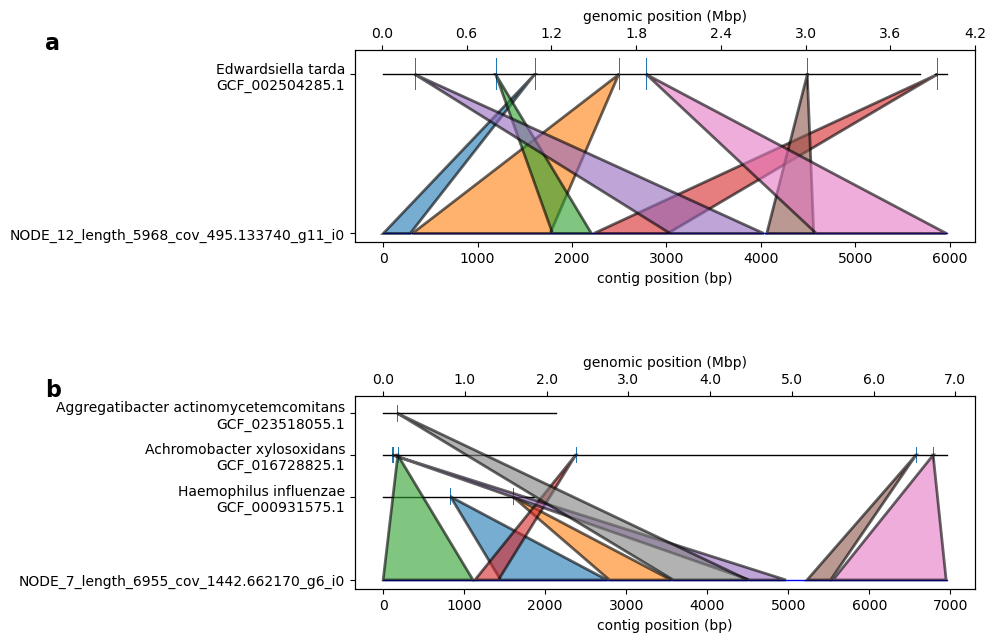

In [18]:
sel_contigs = ['NODE_12_length_5968_cov_495.133740_g11_i0', 'NODE_7_length_6955_cov_1442.662170_g6_i0']

fig, axes = plt.subplots(len(sel_contigs), 1, figsize=(8, 3.5 * len(sel_contigs)),
                         gridspec_kw={"hspace": 0.8})
for i, (ax, contig) in enumerate(zip(axes, sel_contigs)):
    _ = plot_hit_genomes_mapping(mosaic_chimera[mosaic_chimera['Query sequence name'] == contig], ax)
    ax.text(-0.5, 1.00, chr(97+i), transform=ax.transAxes, fontsize=16, fontweight='bold',)
savefig(fig, 'supp-figure_02-example_mosaic_chimera')

### Supplementary Figure 3, N-runs

In [31]:
contigs = filter_for_assembler_with_ns(fp_orb_basedir, orb_settings)

Compiling data for n plot: 100%|██████████| 6/6 [00:00<00:00, 68.72it/s]


Drawing panels for Ns plot: 6it [00:00, 10.79it/s]


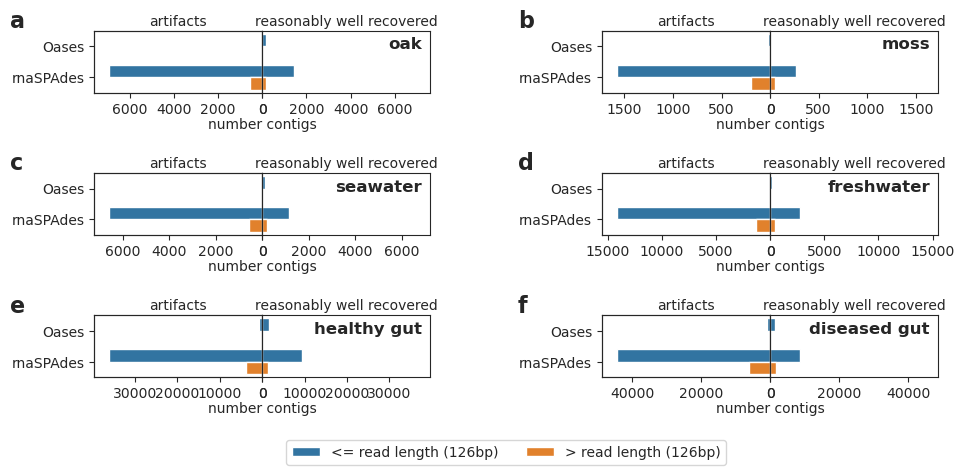

In [20]:
f = plot_nruns(fp_orb_basedir, orb_settings, num_columns=2, contigs=contigs)
savefig(f, "supp-figure_03-nruns")

#### the inclusion of N-runs still leads to 19.9% and 55.4% of N-run containing contigs being classified as reasonably well recovered for rnaSPAdes and Oases

In [38]:
data = pd.concat(contigs).reset_index().rename(columns={'level_0': 'environment'}).groupby(['assembler', 'max_n_longer_read_length', 'environment', 'class']).size().unstack()
data = data['recovered'] / data.sum(axis=1)
data.reset_index().groupby(['assembler'])[0].mean().sort_values()

assembler
rnaSPAdes    0.199662
Oases        0.554201
Name: 0, dtype: float64

#### Only rnaSPAdes integrates N-runs longer than read length, with similar success regarding recovery of 23.3% compared to N-runs shorter than read length with a recovery rate of 16.6%.

In [39]:
data.loc['rnaSPAdes', :].unstack().mean(axis=1).sort_values(ascending=False)

max_n_longer_read_length
> read length     0.233148
<= read length    0.166177
dtype: float64

#### However, most of rnaSPAdes' contigs with N-runs are not reasonably well recovered.

In [41]:
data = pd.concat(contigs).reset_index().rename(columns={'level_0': 'environment'}).set_index('assembler').loc['rnaSPAdes', :].groupby(['environment', 'single_recovery']).size().unstack()
(data['missed'] / data.sum(axis=1)).mean()

0.8281039075833773

#### On average, two thirds of rnaSPAdes' N-run containing contigs are "mosaic chimera".

In [42]:
res = []
for env in get_environments(fp_orb_basedir, orb_settings):
    contig_classes = pd.read_csv(os.path.join(fp_orb_basedir, env, 'minimap2classification/%s_minimap2_categories.tsv' % assembler), sep="\t", index_col=1)
    contig_classes = contig_classes[contig_classes['category'] == 'minimap2_chimeric']
    contig_classes
    
    nruns = pd.read_csv(os.path.join(fp_orb_basedir, env, 'minimap2classification/%s_contig_n_stats.tsv' % assembler), sep="\t", index_col=0)
    nruns = nruns[nruns['total_Ns'] > 0]
    nruns['has_nrun'] = 'yes'
    r = nruns.merge(contig_classes[['category']], left_index=True, right_index=True, how='outer').fillna({'has_nrun': 'no', 'category': 'reasonably well recovered'}).groupby(['has_nrun', 'category']).size().rename(env)
    res.append(r)
res = pd.concat(res,axis=1)
(res.loc['yes', 'minimap2_chimeric'] / res.loc['yes', :].sum()).mean()

0.6989153420060495

#### Programs Trinity and Trans-ABySS always rank best, while dbg and Oases almost always rank last.

In [45]:
def get_entropy_meanrank(ranks, category='rank_recovery'):
    res = pd.pivot_table(data=ranks, index='assembler', columns='environment', values=category)
    res['shift'] = res.apply(lambda rs: sum([abs(r - np.mean(rs)) for r in rs]), axis=1)
    res['mean'] = res.mean(axis=1)
    res.name = category
    return res.sort_values(by='mean')

ranks = data_recovery['rank_recovery'].to_frame()
get_entropy_meanrank(ranks, 'rank_recovery')

environment,diseased_gut,freshwater,healthy_gut,moss,oak,seawater,shift,mean
assembler,,,,,,,,
Trinity,1.0,1.0,1.0,1.0,2.0,1.0,1.666667,1.238095
Trans-ABySS,2.0,2.0,2.0,2.0,1.0,2.0,1.666667,1.809524
SOAPdenovo-Trans,5.0,3.0,5.0,3.0,4.0,3.0,5.000000,4.000000
MEGAHIT,6.0,4.0,7.0,4.0,3.0,4.0,7.333333,5.047619
IDBA-MT,3.0,6.0,3.0,6.0,5.0,6.0,7.333333,5.190476
rnaSPAdes,8.0,5.0,6.0,5.0,7.0,5.0,6.000000,6.000000
IDBA-tran,4.0,7.0,4.0,7.0,6.0,7.0,7.333333,6.047619
Oases,7.0,8.0,8.0,8.0,8.0,8.0,1.666667,6.952381
dbg,9.0,9.0,9.0,9.0,9.0,9.0,0.000000,7.714286


## Short, low covered transcripts are challenging. Path extension and functional redundancy should be leveraged.

In [46]:
data_block_recovery = getdata_block_recovery(fp_orb_basedir, fp_marbel_basedir, marbel_sequence_file, orb_settings, verbose)

Compiling data for DE orthogroup plot:
  1/6: oak
    a) read blocks.bed as pandas.DataFrame ...done.
    b) read gene_summary.csv as pandas.DataFrame ...done.
    c) calculating OG sequence identity:
       done.
  2/6: moss
    a) read blocks.bed as pandas.DataFrame ...done.
    b) read gene_summary.csv as pandas.DataFrame ...done.
    c) calculating OG sequence identity:
       done.
  3/6: seawater
    a) read blocks.bed as pandas.DataFrame ...done.
    b) read gene_summary.csv as pandas.DataFrame ...done.
    c) calculating OG sequence identity:
       done.
  4/6: freshwater
    a) read blocks.bed as pandas.DataFrame ...done.
    b) read gene_summary.csv as pandas.DataFrame ...done.
    c) calculating OG sequence identity:
       done.
  5/6: healthy_gut
    a) read blocks.bed as pandas.DataFrame ...done.
    b) read gene_summary.csv as pandas.DataFrame ...done.
    c) calculating OG sequence identity:
       done.
  6/6: diseased_gut
    a) read blocks.bed as pandas.DataFrame ..

### Supplementary Figure 4, block length

Drawing panels for block_length plot: 6it [01:09, 11.53s/it]


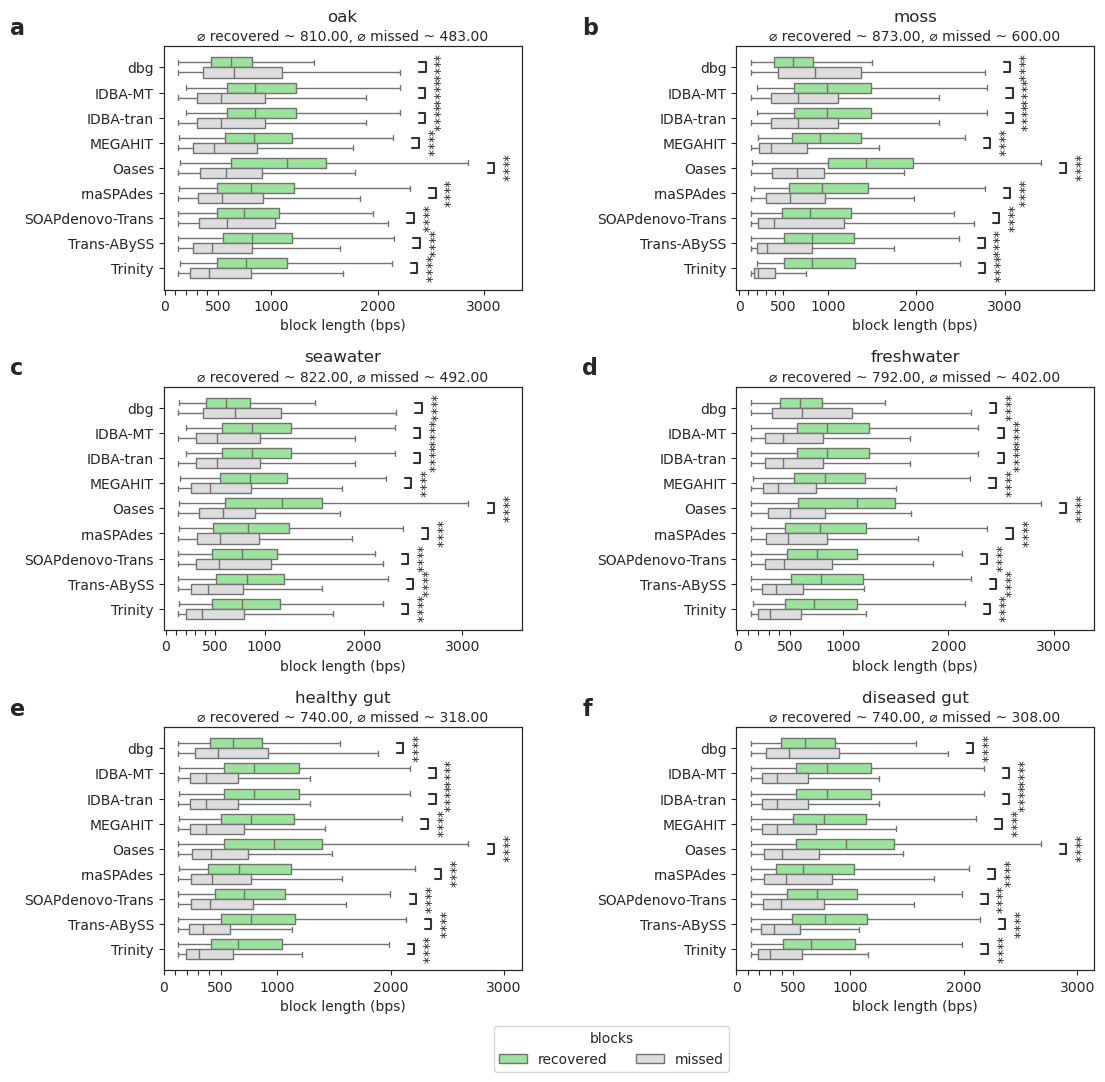

In [47]:
f = plot_block_correlation(fp_orb_basedir, fp_marbel_basedir, marbel_sequence_file, orb_settings, "block_length", data_block_recovery=data_block_recovery, num_columns=2, test='Mann-Whitney')
savefig(f, "supp-figure_04-blockrecovery_blocklength")

### Supplementary Figure 5, coverage

Drawing panels for Coverage plot: 6it [01:20, 13.35s/it]


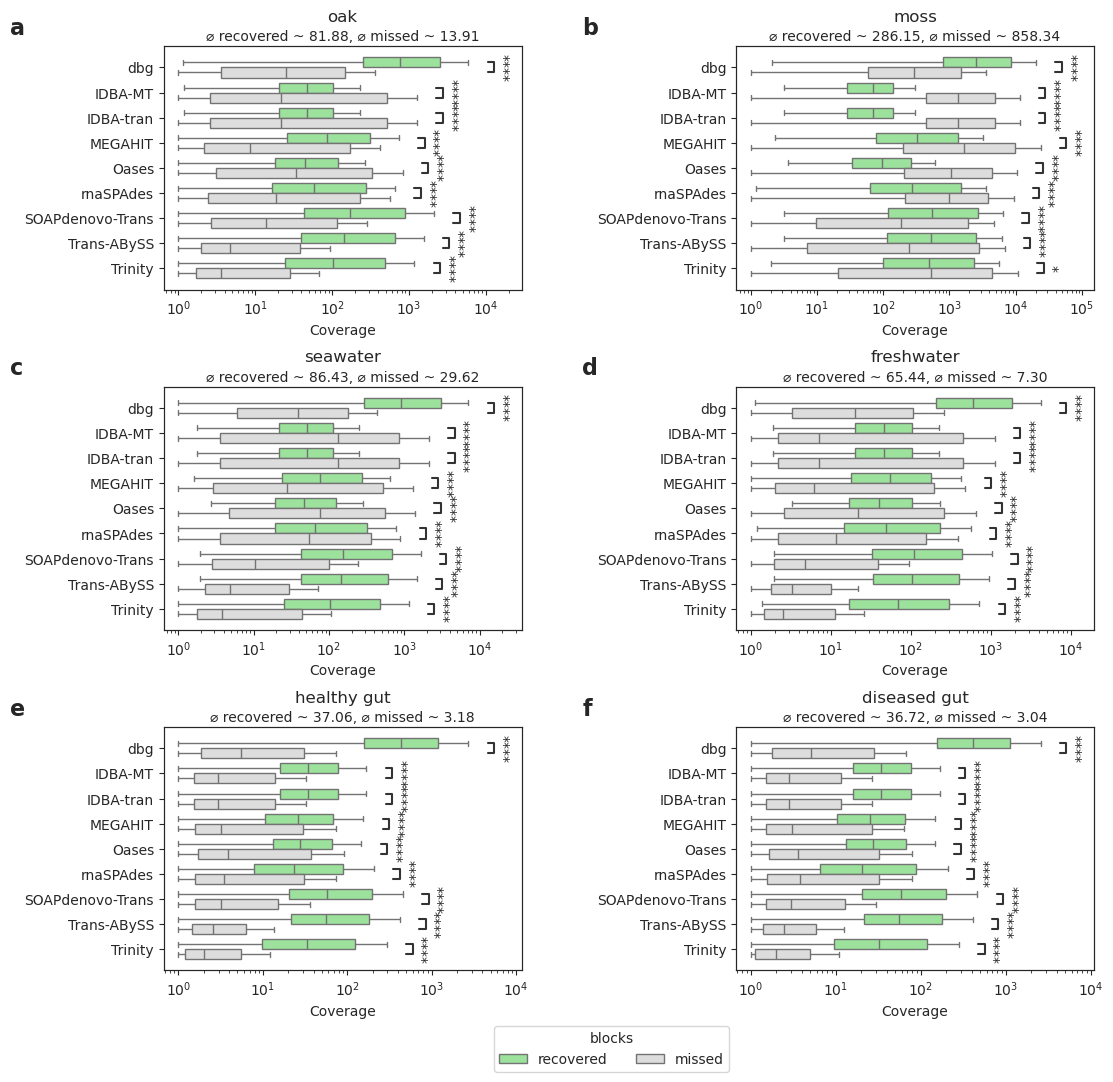

In [48]:
f = plot_block_correlation(fp_orb_basedir, fp_marbel_basedir, marbel_sequence_file, orb_settings, "Coverage", data_block_recovery=data_block_recovery, num_columns=2, logscale=True, test='Mann-Whitney')
savefig(f, "supp-figure_05-blockrecovery_coverage")

### Supplementary Figure 6, shorter block coverage

100%|██████████| 6/6 [01:39<00:00, 16.52s/it]
Drawing panels for Coverage plot: 6it [01:08, 11.48s/it]


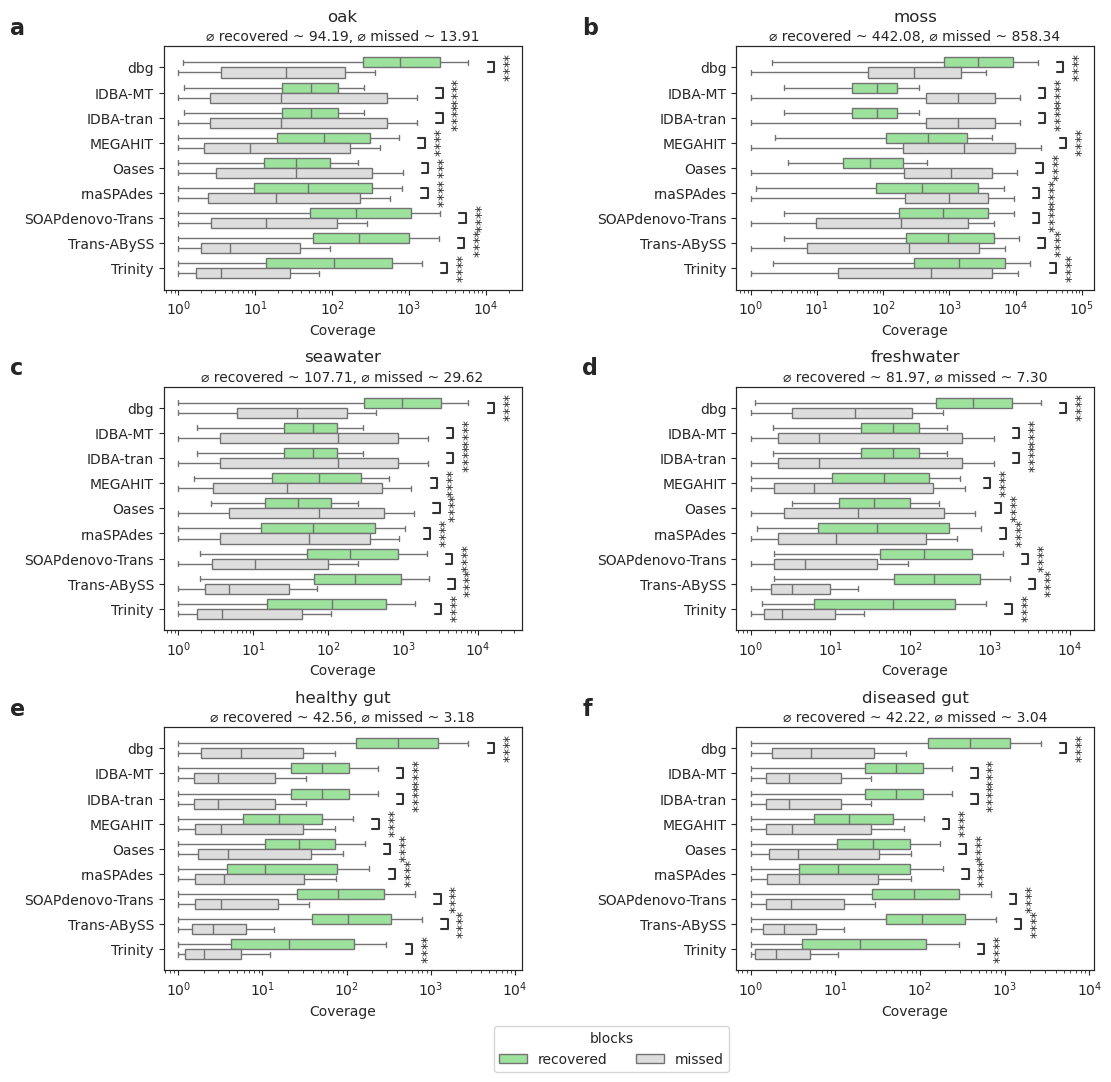

In [49]:
samelenblocks = dict()
for env in tqdm(get_environments(fp_orb_basedir, orb_settings)): 
    thresholds = data_block_recovery[env][data_block_recovery[env]['is_recovered'] == False].groupby('assembler')['block_length'].describe()['75%']
    x = data_block_recovery[env].apply(lambda row: (row['is_recovered'] == True) & (row['block_length'] > thresholds[row['assembler']]), axis=1)
    samelenblocks[env] = data_block_recovery[env][~x]

f = plot_block_correlation(fp_orb_basedir, fp_marbel_basedir, marbel_sequence_file, orb_settings, "Coverage", data_block_recovery=samelenblocks, num_columns=2, logscale=True, test='Mann-Whitney')
savefig(f, "supp-figure_06-blockrecovery_coverage-nolargerblocks")

#### However, we observe from our data across all environments and all assembler results that 95% of recovered contigs have a coverage of at least 4.

In [50]:
for env in get_environments(fp_orb_basedir, orb_settings):
    print(data_block_recovery[env][data_block_recovery[env]['is_recovered'] == True]['Coverage'].describe(percentiles=[.05, .1, .25, .5])['5%'],
          env)

6.310177705977383 oak
13.83529411764706 moss
6.604838709677419 seawater
5.6 freshwater
4.176795580110498 healthy_gut
4.1066666666666665 diseased_gut


### Supplementary Figure 7, sequence similarity

Drawing panels for mean_identity plot: 6it [01:13, 12.31s/it]


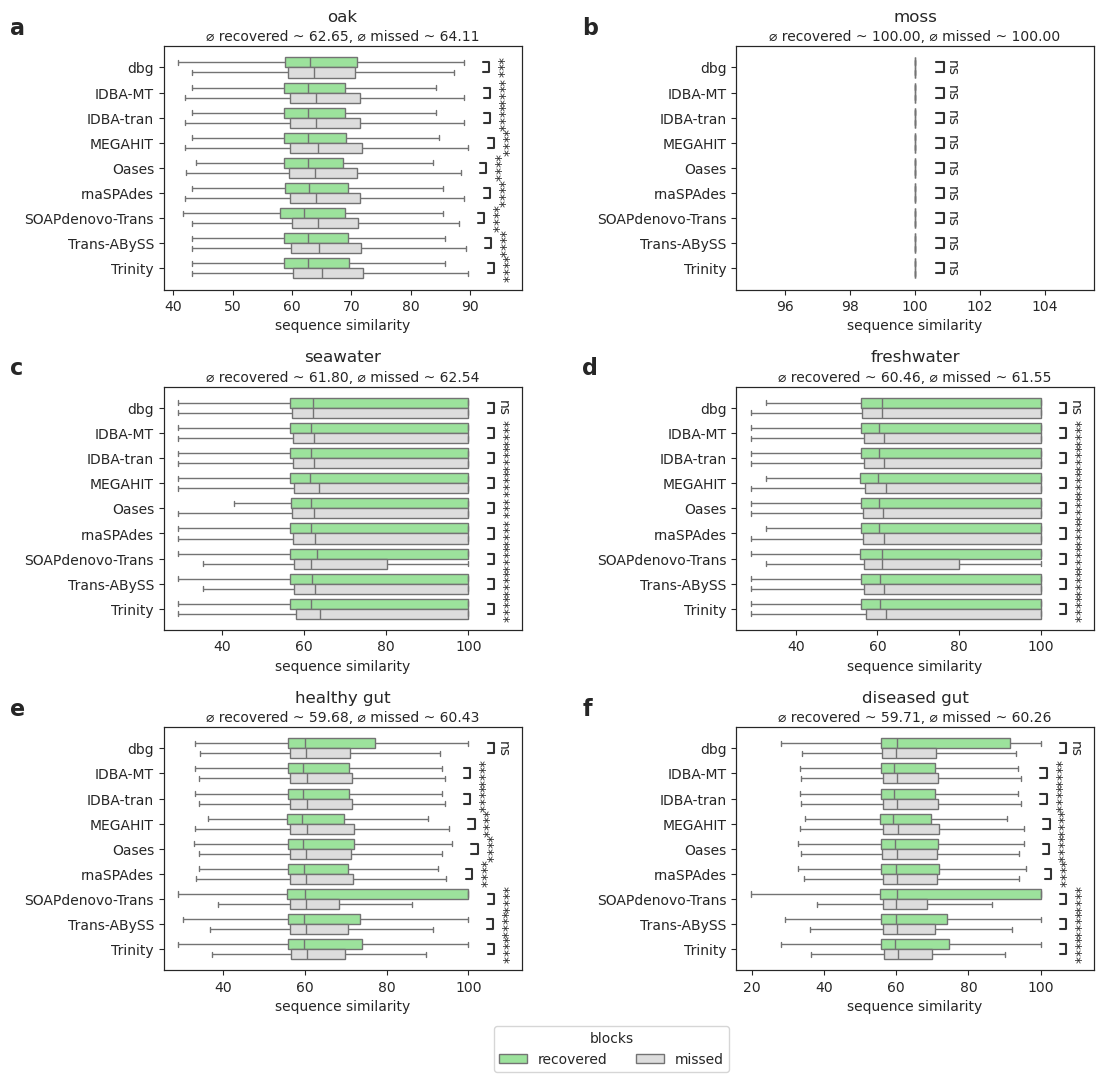

In [51]:
f = plot_block_correlation(fp_orb_basedir, fp_marbel_basedir, marbel_sequence_file, orb_settings, "mean_identity", data_block_recovery=data_block_recovery, num_columns=2, test='Mann-Whitney')
savefig(f, "supp-figure_07-blockrecovery_seqidentity")

## Total agreement of assemblers is low - choice should depend on community complexity, expected ratio of taxonomic redundancy and available compute resources.

In [52]:
recovered_genes = getdata_gene_recovery(fp_orb_basedir, orb_settings)

Compiling data for gene recovery plot: 100%|██████████| 6/6 [00:14<00:00,  2.43s/it]
Compute sets of unique/shared/core genes for gene recovery plot: 100%|██████████| 6/6 [00:24<00:00,  4.06s/it]


### Figure 3

Drawing panels for gene recovery plot: 6it [00:00, 12.39it/s]


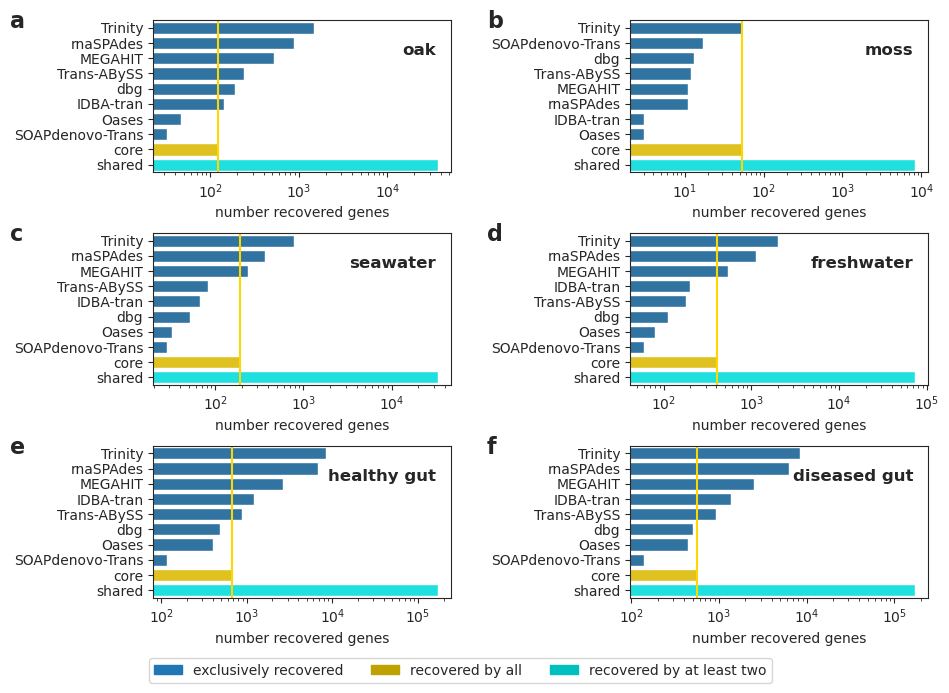

In [53]:
f = plot_gene_recovery(fp_orb_basedir, orb_settings, num_columns=2, recovered_genes=recovered_genes)
savefig(f, "figure_3-generecovery")

#### We detected only a small total agreement for all assemblers (approximately 0.44% for all datasets)

In [54]:
'%.2f%%' % ((recovered_genes.loc['core', :] / recovered_genes.loc['total', :]).mean() * 100)

'0.44%'

#### Trinity recovers the most unique genes | Surprisingly, even though rnaSPAdes is ranked poorly in contig recovery, it recovers the second largest set of unique genes.


In [55]:
recovered_genes.iloc[:-3, :].sum(axis=1).sort_values(ascending=False)

assembler
Trinity             21190
rnaSPAdes           15407
MEGAHIT              6516
IDBA-tran            3014
Trans-ABySS          2299
dbg                  1359
Oases                1009
SOAPdenovo-Trans      390
dtype: int64

### Supplementary Figure 8

Compiling data for gene recovery plot: 100%|██████████| 6/6 [00:08<00:00,  1.44s/it]
Compute heatmap: 8it [00:06,  1.20it/s]


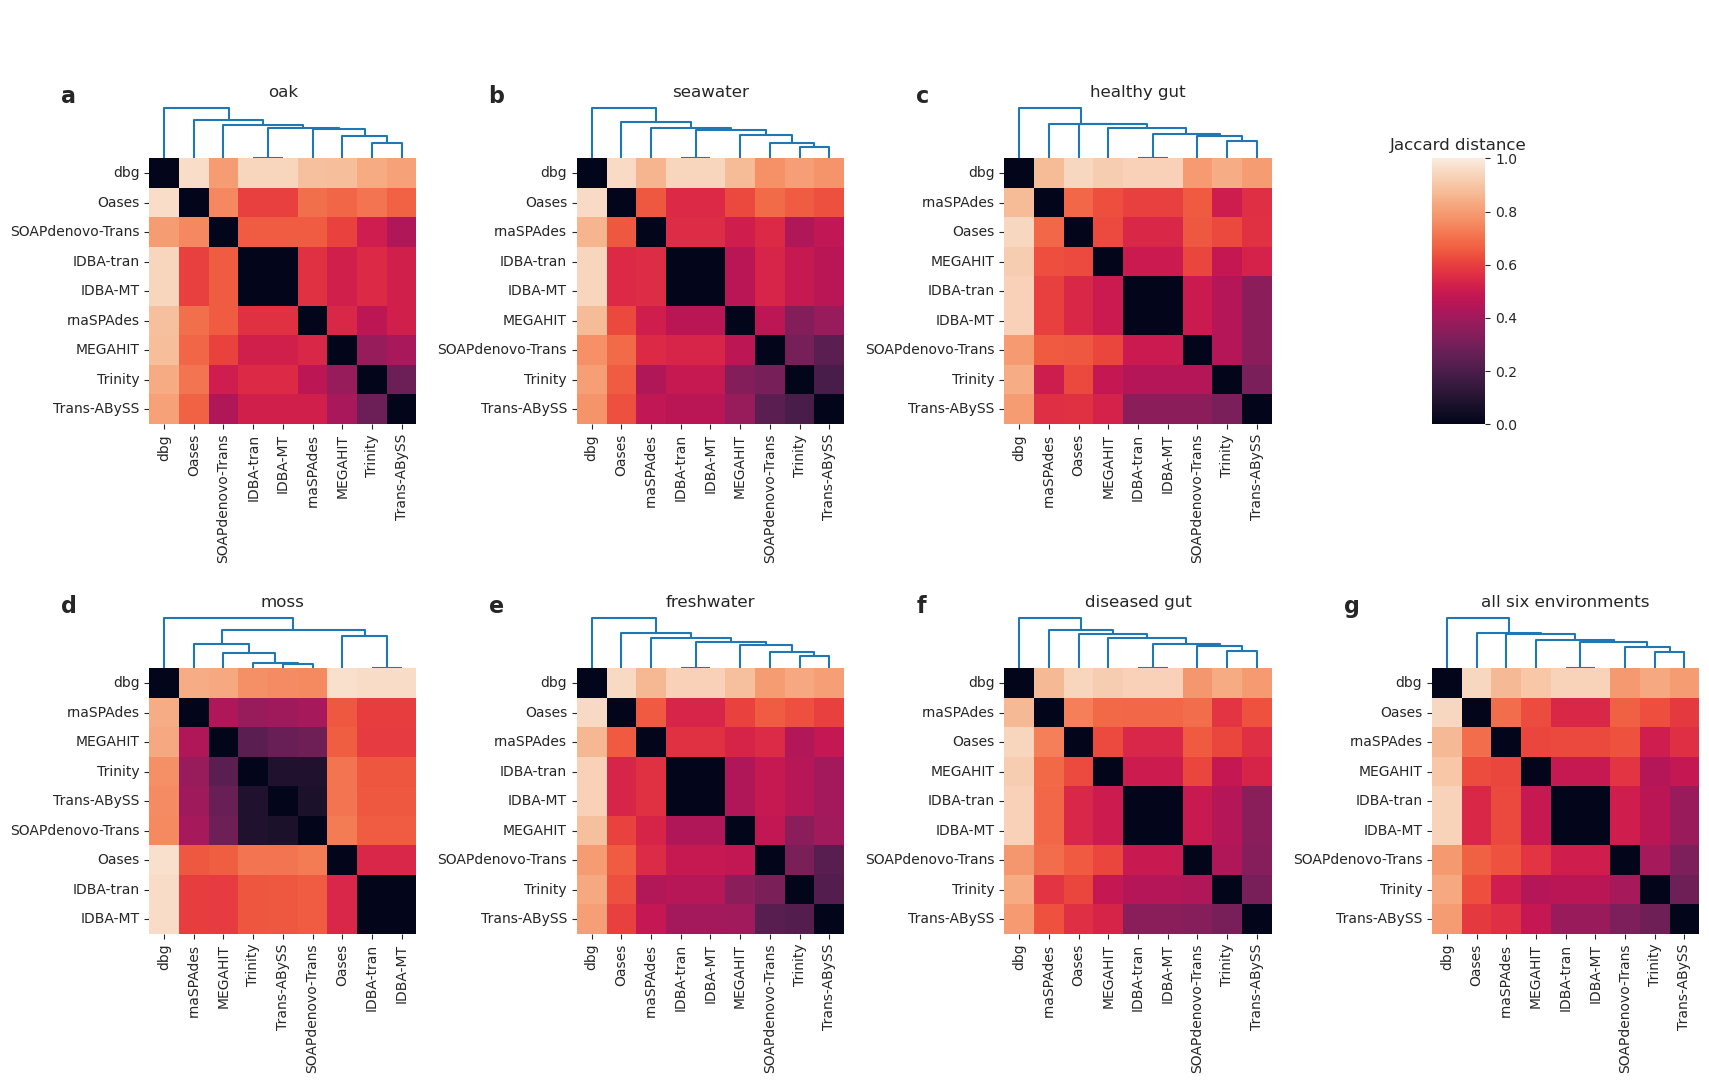

In [56]:
f = plot_heatmap(fp_orb_basedir, orb_settings, num_columns=3)
savefig(f, "supp-figure_08-heatmaps")

### Figure 4

Compiling data for runtime/memory footprint plot: 100%|██████████| 72/72 [00:03<00:00, 23.81it/s]


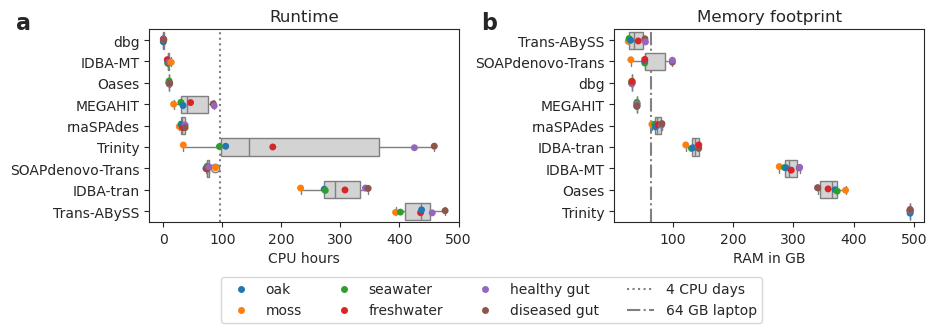

In [57]:
f = plotTimeMemory(fp_caviar_basedir, orb_settings, verbose)
savefig(f, "figure_4-runtime")

## Differential expression evaluation with ORB reveals different ranking compared to recovery success.

In [58]:
DEfeatures = getdata_DEgenes_mod(fp_orb_basedir, orb_settings, verbose, sortF1=True)
ranks['rank_DEgenes'] = DEfeatures.loc[:, :, 'True Positive']['rank'].astype(int)
#rank_data = getdata_recovery(fp_orb_basedir, orb_settings, verbose=verbose)
#ranks_DE = DEfeatures.reset_index().groupby(['environment', 'assembler']).head(1).set_index(['environment', 'assembler'])['rank']
#rank_recovery = rank_data.reset_index().rename(columns={'index': 'assembler'}).set_index(['environment', 'assembler'])['recovery_rank']

Compiling data for DE gene plot: 100%|██████████| 6/6 [00:02<00:00,  2.35it/s]


### Figure 5

Compiling data for contig recovery plot: 100%|██████████| 6/6 [00:00<00:00,  7.23it/s]
Drawing panels for DE plot: 6it [00:00, 18.60it/s]


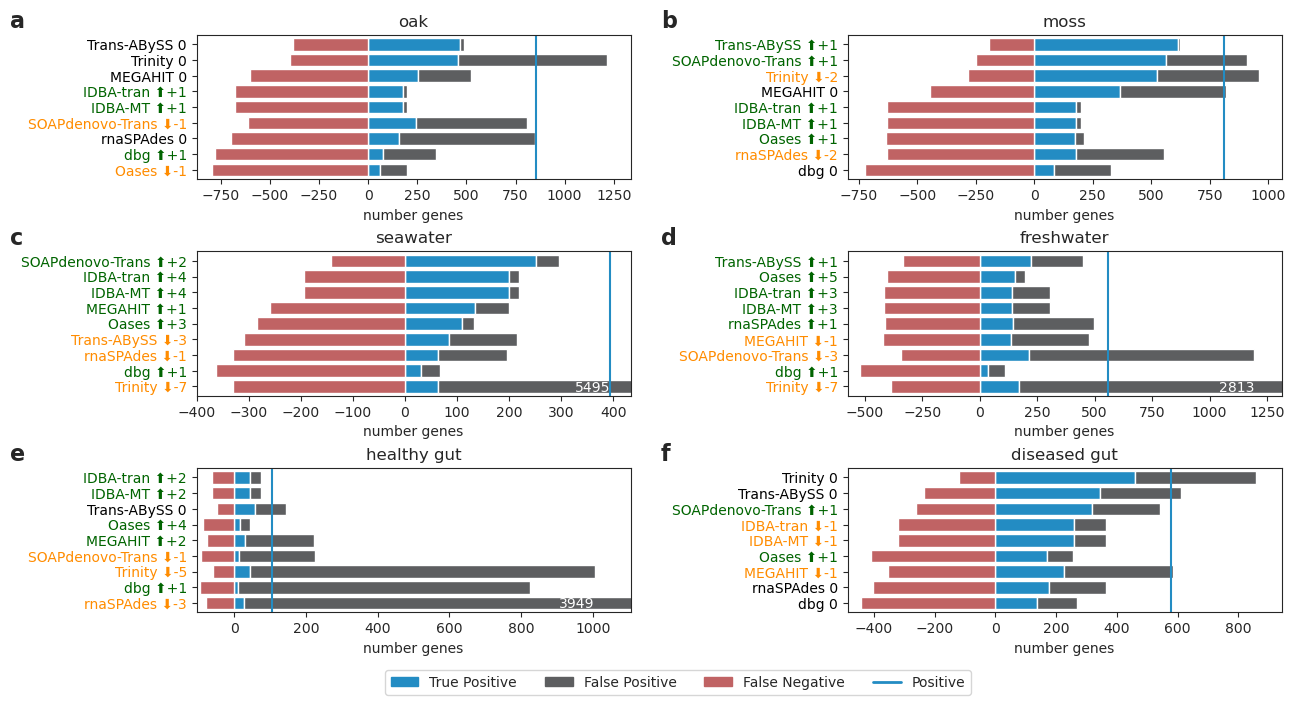

In [59]:
f = plot_DEgenes(fp_orb_basedir, orb_settings, num_columns=2, sortF1=True)
savefig(f, "figure_5-dGe")

#### For the environment with characteristics no orthology (moss), lower gene count (seawater), and high differential expression (diseased gut) approx. 73% of the true positives can be identified on average with the best assembler.

In [60]:
data_DEcontigs = DEfeatures['num_genes'].unstack()
data_DEcontigs = (data_DEcontigs['True Positive'] / data_DEcontigs[['True Positive', 'False Negative']].sum(axis=1)).reset_index().sort_values(by=0, ascending=False).groupby('environment').head(1)
data_DEcontigs.set_index('environment').loc[['moss', 'seawater', 'diseased_gut'], 0].mean()

0.7299999088613305

#### On the other hand, only approx. 50% of the true positives can be identified on average for the environments with characteristics high orthology (oak), high gene count (freshwater), and high species count, but unaltered differential expression (healthy gut).

In [61]:
data_DEcontigs.set_index('environment').loc[['oak', 'freshwater', 'healthy_gut'], 0].mean()

0.5016288796669642

#### Performance of SOPAdenovo-Trans follows this characterization surprisingly well, ranking best, second best and third place for seawater, moss and diseased gut, respectively

In [62]:
ranks.loc[['seawater', 'moss', 'diseased_gut'], 'SOAPdenovo-Trans', :]['rank_DEgenes']

environment   assembler       
seawater      SOAPdenovo-Trans    1
moss          SOAPdenovo-Trans    2
diseased_gut  SOAPdenovo-Trans    3
Name: rank_DEgenes, dtype: int64

#### and drops to the lower half for the other environments.

In [63]:
ranks.loc[['freshwater', 'oak', 'healthy_gut'], 'SOAPdenovo-Trans', :]['rank_DEgenes']

environment  assembler       
freshwater   SOAPdenovo-Trans    7
oak          SOAPdenovo-Trans    6
healthy_gut  SOAPdenovo-Trans    6
Name: rank_DEgenes, dtype: int64

#### Overall, Trans-ABySS is the most successful assembler with regards to DE identification.

In [64]:
ranks['rank_DEgenes'].unstack().T.mean(axis=1).sort_values()

assembler
Trans-ABySS         2.333333
IDBA-tran           3.166667
IDBA-MT             4.166667
SOAPdenovo-Trans    4.166667
MEGAHIT             4.833333
Trinity             5.166667
Oases               5.500000
rnaSPAdes           7.333333
dbg                 8.333333
dtype: float64

#### Surprisingly, Trinity, which ranked best for recovery, lost the most ranks | the IDBA assemblers could make up most places.

In [65]:
(ranks['rank_recovery'] - ranks['rank_DEgenes']).reset_index().groupby('assembler')[0].sum().sort_values() #.unstack()

assembler
Trinity            -24
rnaSPAdes           -8
Trans-ABySS         -3
SOAPdenovo-Trans    -2
MEGAHIT             -1
IDBA-MT              4
dbg                  4
Oases               14
IDBA-tran           16
Name: 0, dtype: int64

#### due to moderate true positive

In [66]:
fields = ['False Negative', 'False Positive', 'True Positive']
data = DEfeatures['num_genes'].unstack()[fields]
data = ((data.T / data.sum(axis=1)).T).reset_index().groupby('assembler')[fields].mean()
data['True Positive'].sort_values()

assembler
dbg                 0.079305
rnaSPAdes           0.128041
Oases               0.194622
Trinity             0.213143
MEGAHIT             0.216263
IDBA-MT             0.297739
IDBA-tran           0.297739
SOAPdenovo-Trans    0.301571
Trans-ABySS         0.408623
Name: True Positive, dtype: float64

#### but on average highest false positive ratios (64.9% of recovered contigs) | IDBA: only 11.8% result in false positive DE predictions

In [67]:
data['False Positive'].sort_values()

assembler
Oases               0.108623
IDBA-MT             0.118365
IDBA-tran           0.118365
Trans-ABySS         0.222459
dbg                 0.291659
MEGAHIT             0.358878
SOAPdenovo-Trans    0.397330
rnaSPAdes           0.437303
Trinity             0.649448
Name: False Positive, dtype: float64

#### Ranking position for the other assemblers vary much stronger with tested environment than for contig recovery, though.

In [68]:
pd.concat([
    get_entropy_meanrank(ranks, 'rank_recovery')['shift'].rename('shift_recovery'),
    get_entropy_meanrank(ranks, 'rank_DEgenes')['shift'].rename('shift_DEgenes')], axis=1)

,shift_recovery,shift_DEgenes
assembler,,
Trinity,1.666667,19.000000
Trans-ABySS,1.666667,8.666667
SOAPdenovo-Trans,5.000000,13.000000
MEGAHIT,7.333333,7.000000
IDBA-MT,7.333333,7.000000
rnaSPAdes,6.000000,6.000000
IDBA-tran,7.333333,7.000000
Oases,1.666667,11.000000
dbg,0.000000,2.666667


## Collapsing genes into orthologous groups leads to higher confidence in detecting functional changes.

### Figure 6

Compiling data for DE Venn diagram: 100%|██████████| 6/6 [00:07<00:00,  1.18s/it]
Drawing panels for DE Venn diagrams: 0it [00:00, ?it/s]/homes/sjanssen/miniconda3/envs/ggmap_new/lib/python3.12/site-packages/matplotlib_venn/layout/venn2/exact.py:83: UserWarning: Both circles have zero area
  warnings.warn("Both circles have zero area")
Drawing panels for DE Venn diagrams: 6it [00:00, 10.94it/s]


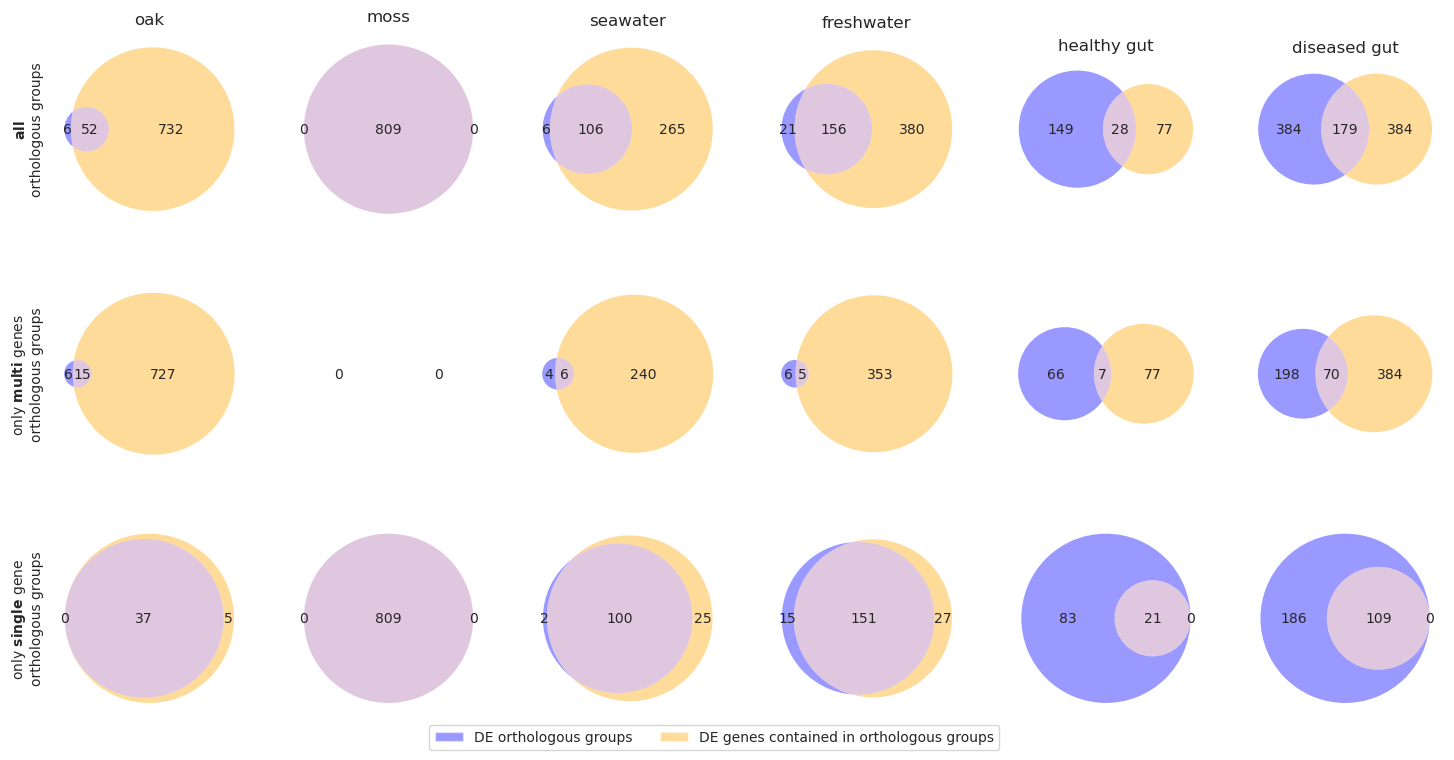

In [69]:
f = plot_DEvennOrtho(fp_orb_basedir, fp_marbel_basedir, orb_settings)
savefig(f, "figure_6-vennOGs")

### Figure 7

Compiling data for DE orthogroups plot: 100%|██████████| 6/6 [00:03<00:00,  1.99it/s]
Drawing panels for DE plot: 6it [00:00, 19.54it/s]


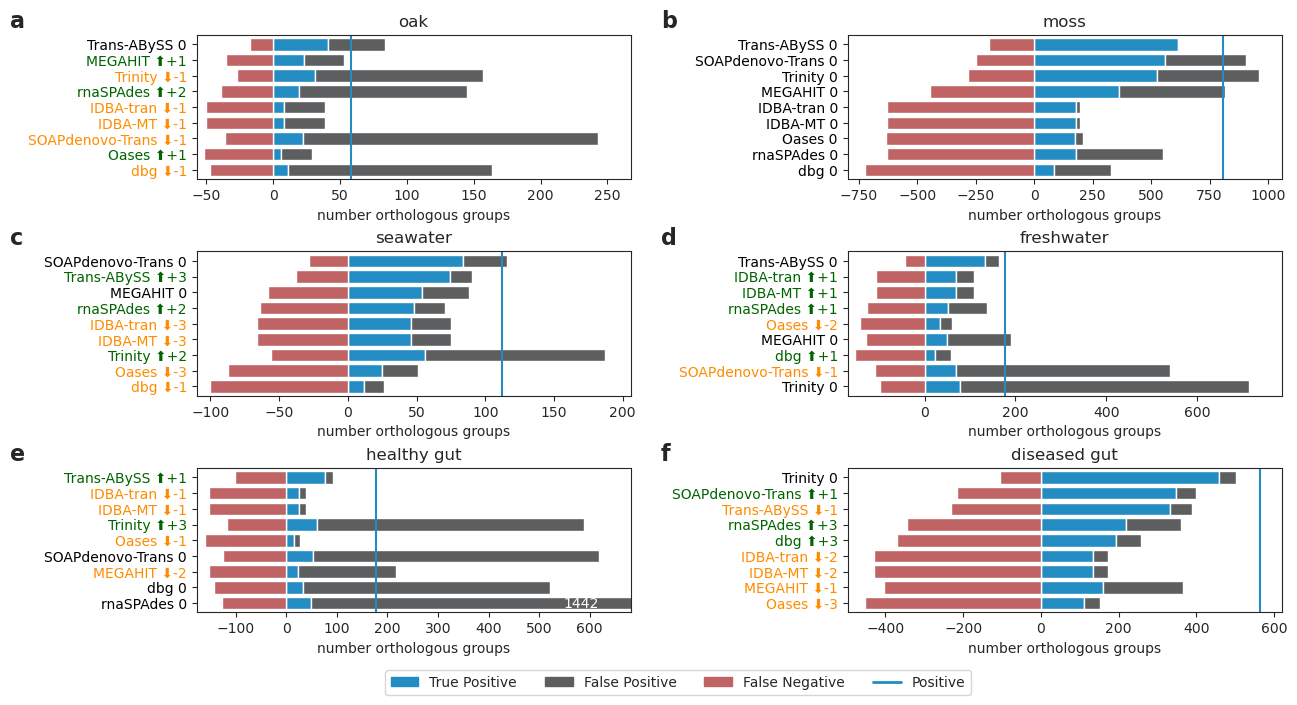

In [70]:
xOG = plot_DEgenes(fp_orb_basedir, orb_settings, True, num_columns=2, sortF1=True)
savefig(xOG, "figure_7-dOGe")

In [71]:
DEog = getdata_DEorthogroups_mod(fp_orb_basedir, orb_settings, sortF1=True)
ranks["rank_DEogs"] = DEog.loc[:, :, 'True Positive']['rank'].astype(int)

Compiling data for DE orthogroups plot: 100%|██████████| 6/6 [00:00<00:00, 26.77it/s]


#### In general, the number of positive orthologous groups is smaller than the number of positive genes (blue vertical lines in both figures, except the healthy gut environment)

In [72]:
pd.concat([
    DEfeatures.loc[:, :, ['True Positive', 'False Negative']]['num_genes'].unstack().sum(axis=1).loc[:, 'dbg', :].rename('positives_contigs'),
    DEog.loc[:, :, ['True Positive', 'False Negative']]['num_genes'].unstack().sum(axis=1).loc[:, 'dbg', :].rename('positives_OG')], axis=1)

,positives_contigs,positives_OG
environment,,
diseased_gut,579,563
freshwater,557,177
healthy_gut,105,177
moss,809,809
oak,854,58
seawater,394,112


#### the fraction of successfully identified true positives increases on average by 16.2%

In [73]:
fields = ['False Negative', 'True Positive']
data = DEfeatures['num_genes'].unstack()[fields]
data = ((data.T / data.sum(axis=1)).T)['True Positive'].rename('contigs')#.reset_index()#.groupby('assembler')[fields].mean()

dataOG = DEog['num_genes'].unstack()[fields]
dataOG = ((dataOG.T / dataOG.sum(axis=1)).T)['True Positive'].rename('OG')#.reset_index().groupby('assembler')[fields].mean()

data = pd.concat([data, dataOG], axis=1)
data = pd.concat([
    data['contigs'].reset_index().groupby('environment')['contigs'].max(),
    data['OG'].reset_index().groupby('environment')['OG'].max()], axis=1)
data['delta'] = data['OG'] - data['contigs']

data

,contigs,OG,delta
environment,,,
diseased_gut,0.792746,0.815275,0.022529
freshwater,0.402154,0.757062,0.354908
healthy_gut,0.552381,0.429379,-0.123002
moss,0.760198,0.760198,0.000000
oak,0.550351,0.706897,0.156545
seawater,0.637056,0.750000,0.112944


In [74]:
data.loc[['diseased_gut', 'freshwater', 'oak', 'seawater'], 'delta'].mean()

0.16173159281964436

#### except for the healthy gut environment with a decrease by 12.3% and the moss environment with almost unchanged performance.

In [75]:
data.loc[['healthy_gut', 'moss'], :]

,contigs,OG,delta
environment,,,
healthy_gut,0.552381,0.429379,-0.123002
moss,0.760198,0.760198,0.000000


#### This is reflected in small discrepancies observed in moss, e.g. number of false positives for MEGAHIT

In [76]:
(DEfeatures.loc['moss', :, :]['num_genes'] - DEog.loc['moss', :, :]['num_genes']).sort_values() #.reset_index()#.sort_values()

assembler         class         
MEGAHIT           True Negative    -3
IDBA-MT           True Negative    -2
IDBA-tran         True Negative    -2
Trinity           True Positive    -1
Oases             True Negative    -1
SOAPdenovo-Trans  True Negative    -1
dbg               True Positive     0
                  False Positive    0
                  False Negative    0
Trans-ABySS       False Negative    0
rnaSPAdes         False Negative    0
Trinity           True Negative     0
                  False Positive    0
Trans-ABySS       True Positive     0
rnaSPAdes         False Positive    0
Trans-ABySS       True Negative     0
                  False Positive    0
dbg               True Negative     0
IDBA-MT           False Negative    0
rnaSPAdes         True Positive     0
                  True Negative     0
SOAPdenovo-Trans  False Negative    0
Oases             True Positive     0
                  False Negative    0
MEGAHIT           True Positive     0
                 

#### however, this effect is too small to change assembler ranking.

In [77]:
DEog.loc['moss', :, 'True Positive']['rank'] - DEfeatures.loc['moss', :, 'True Positive']['rank']

assembler
IDBA-MT             0.0
IDBA-tran           0.0
MEGAHIT             0.0
Oases               0.0
SOAPdenovo-Trans    0.0
Trans-ABySS         0.0
Trinity             0.0
dbg                 0.0
rnaSPAdes           0.0
Name: rank, dtype: float64

#### In general, the number of false positives only slightly declines by 1.7% on average (again, excluding the moss environment).

In [78]:
res = []
data = getdata_DEgenes_mod(fp_orb_basedir, orb_settings, verbose, sortF1=True)
num_true = data[data['truth'] == True].loc[:, 'dbg', :]['num_genes'].unstack().sum(axis=1)
res.append((data.loc[:, :, 'False Negative']['num_genes'] / num_true).reset_index().groupby('environment')[0].max().rename('transcript level'))

data = getdata_DEorthogroups_mod(fp_orb_basedir, orb_settings, sortF1=True)
num_true = data[data['truth'] == True].loc[:, 'dbg', :]['num_genes'].unstack().sum(axis=1)
res.append((data.loc[:, :, 'False Negative']['num_genes'] / num_true).reset_index().groupby('environment')[0].max().rename('OG level'))

res = pd.concat(res, axis=1)
res['diff'] = res['OG level'] - res['transcript level']
res.loc[['diseased_gut', 'freshwater', 'oak', 'seawater', 'healthy_gut'], 'diff'].mean()


Compiling data for DE orthogroups plot: 100%|██████████| 6/6 [00:00<00:00, 30.63it/s]


-0.017165584228762975

#### Turning to changes in ranking, rnaSPAdes leverages orthologous grouping most successfully, visible by making up eleven rank positions in total. | The already very successful Trans-ABySS assembler even improves by five rank positions | while Oases and IDBA decline in ranking

In [79]:
rank_shifts = pd.concat([get_rank_shifts(ranks['rank_DEgenes'].loc[[env], :], ranks['rank_DEogs'].loc[[env], :]) for env in list(ranks['rank_DEgenes'].index.levels[0])])
rank_shifts.reset_index().groupby('assembler')['shift'].sum().sort_values(ascending=False)

assembler
rnaSPAdes           11
Trans-ABySS          5
Trinity              4
dbg                  3
MEGAHIT             -1
SOAPdenovo-Trans    -1
IDBA-MT             -6
IDBA-tran           -6
Oases               -9
Name: shift, dtype: int64

####  However, its best ranking remains in the mid-field.

In [80]:
ranks.loc[:, 'rnaSPAdes', :]['rank_DEogs'].sort_values()

environment
oak             4
seawater        4
freshwater      4
diseased_gut    4
moss            8
healthy_gut     9
Name: rank_DEogs, dtype: int64

## Benchmarking metatranscriptomic assembler via Orb adds essential perspectives to existing testbeds like Detonate and rnaQUAST.

### Supplementary Figure 9

Compiling data for contig recovery plot: 100%|██████████| 6/6 [00:00<00:00, 44.42it/s]
Draw RNAquast panels: 6it [00:00, 11.96it/s]


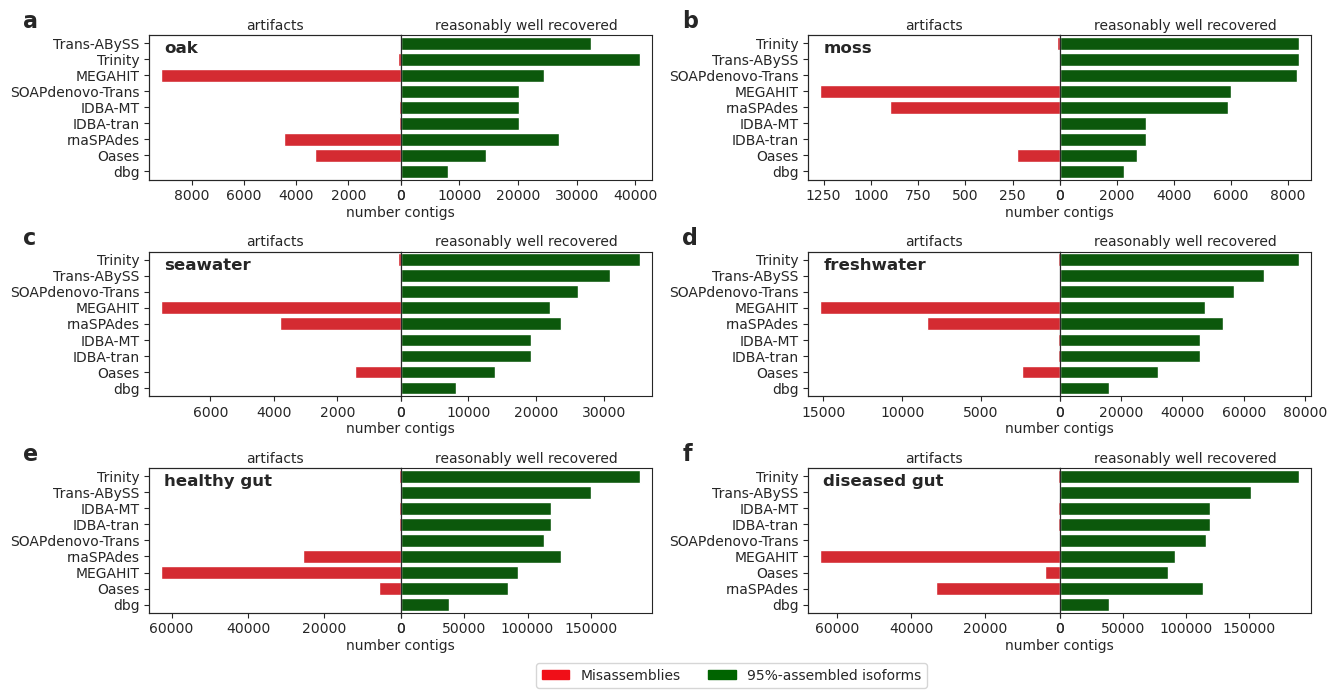

In [81]:
fig = plot_rnaquast(fp_orb_basedir, fp_quast_basedir, orb_settings, num_columns=2)
savefig(fig, "supp-figure_09-quast_goodbad")

#### This metric mostly agrees with our ranking, except for rnaSPAdes, which ranks in all but the moss environment higher in rnaQUAST.

In [82]:
quast = getdata_rnaquast(fp_orb_basedir, fp_quast_basedir, orb_settings).unstack().reset_index()

# rank assemblers according to 95%-assembled isoforms and Database coverage
for field in ['95%-assembled isoforms', 'Database coverage']:
    for env, g in quast.sort_values(by=('score', field), ascending=False).groupby('environment'):
        quast.loc[g.index, 'rank_%s' % field] = range(1, g.shape[0] + 1)
    ranks['rank_%s' % field] = quast.set_index(['environment', 'assembler'])['rank_%s' % field].astype(int)

Compile RNAquast data: 100%|██████████| 6/6 [00:00<00:00, 318.39it/s]


In [83]:
(ranks['rank_recovery'] - ranks['rank_%s' % '95%-assembled isoforms']).unstack().T

environment,diseased_gut,freshwater,healthy_gut,moss,oak,seawater
assembler,,,,,,
IDBA-MT,-1,-1,-1,-1,0,-1
IDBA-tran,1,1,-1,1,0,1
MEGAHIT,-1,-1,0,0,-1,-1
Oases,-1,0,0,0,0,0
SOAPdenovo-Trans,0,0,-1,0,-3,0
Trans-ABySS,0,0,0,1,-1,0
Trinity,0,0,0,-1,1,0
dbg,0,0,0,0,0,0
rnaSPAdes,2,1,3,0,4,1


### Supplementary Figure 10, rnaQuast database coverage

Compiling data for contig recovery plot: 100%|██████████| 6/6 [00:00<00:00, 105.14it/s]
Draw RNAquast panels: 6it [00:00, 28.06it/s]


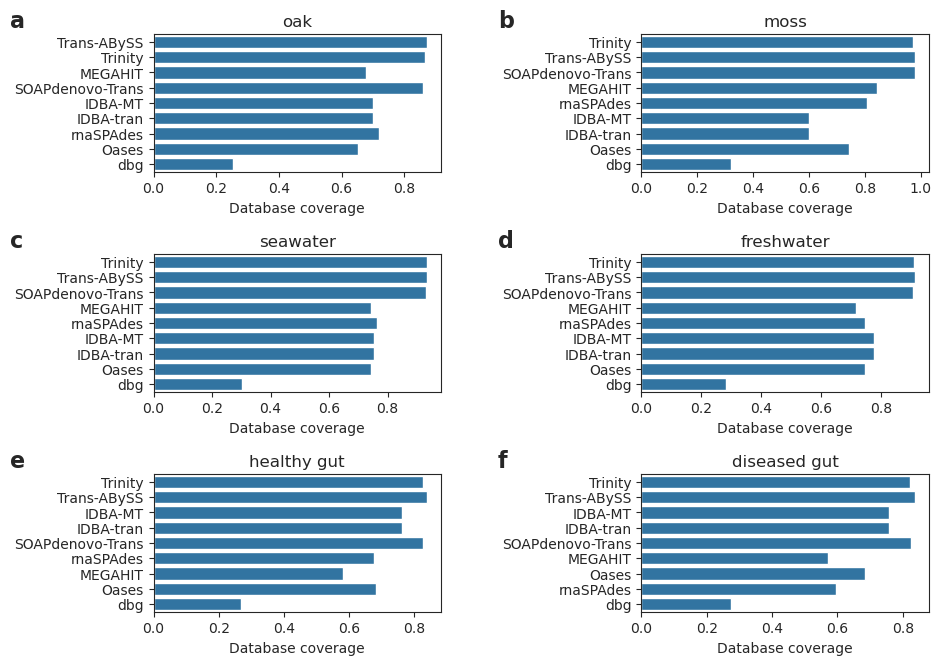

In [84]:
fig = plot_rnaquast_singlescore(fp_orb_basedir, fp_quast_basedir, orb_settings, num_columns=2)
savefig(fig, "supp-figure_10-quast_dbcoverage")

#### Because this does not consider contiguity,  SOAPdenovo-Trans improves its relative ranking.

In [85]:
(ranks['rank_recovery'] - ranks['rank_%s' % 'Database coverage']).unstack().T

environment,diseased_gut,freshwater,healthy_gut,moss,oak,seawater
assembler,,,,,,
IDBA-MT,-2,1,-1,-2,0,0
IDBA-tran,0,3,-1,0,0,2
MEGAHIT,-2,-4,-1,0,-4,-3
Oases,1,1,2,2,0,0
SOAPdenovo-Trans,3,0,3,2,1,0
Trans-ABySS,1,1,1,0,0,1
Trinity,-2,-1,-2,-2,0,-1
dbg,0,0,0,0,0,0
rnaSPAdes,1,-1,-1,0,3,1


### Supplementary Figure 11, detonate

Compiling data for contig recovery plot: 100%|██████████| 6/6 [00:00<00:00, 89.23it/s]
Draw RNAquast panels: 6it [00:00, 26.71it/s]


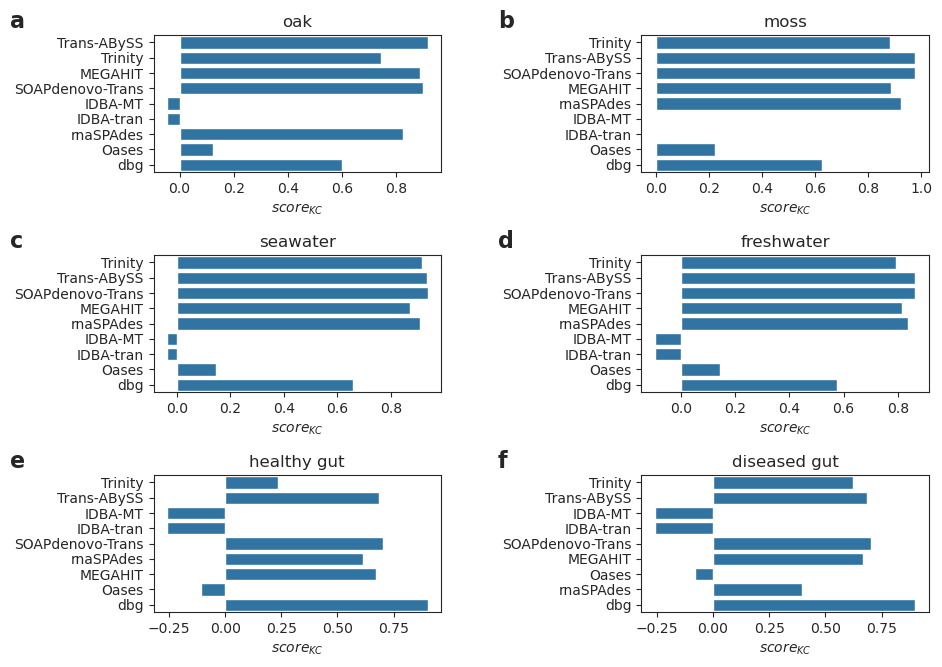

In [86]:
fig = plot_detonate(fp_orb_basedir, fp_detonate_basedir, orb_settings, num_columns=2)
savefig(fig, "supp-figure_11-detonate")

#### it widely disagrees with our performance rankings

In [87]:
detonate = getdata_detonate(fp_orb_basedir, fp_detonate_basedir, orb_settings)
field = 'score_{KC}'
for env, g in detonate.sort_values(by=field, ascending=False).groupby('environment'):
    detonate.loc[g.index, 'rank_%s' % field] = range(1, g.shape[0] + 1)
ranks['rank_%s' % field] = detonate['rank_%s' % field].astype(int)

Compile Detonate data: 100%|██████████| 6/6 [00:00<00:00, 272.95it/s]


In [88]:
#(ranks['rank_recovery'] - ranks['rank_%s' % field]).reset_index().groupby('environment')[0].apply(lambda x: list(x))
r = ranks[['rank_recovery', 'rank_%s' % field]].copy()
r['rank shift'] = r.iloc[:, 0] - r.iloc[:, 1]
r

rank_recovery  rank_score_{KC}  rank shift
environment  assembler                                                   
oak          dbg                           9                6           3
             Oases                         8                7           1
             rnaSPAdes                     7                4           3
             IDBA-tran                     6                8          -2
             IDBA-MT                       5                9          -4
             SOAPdenovo-Trans              4                2           2
             MEGAHIT                       3                3           0
             Trinity                       2                5          -3
             Trans-ABySS                   1                1           0
moss         dbg                           9                6           3
             Oases                         8                7           1
             IDBA-tran                     7                8          -1
             IDBA-MT                       6                9          -3
             rnaSPAdes                     5                3           2
             MEGAHIT                       4                4           0
             SOAPdenovo-Trans              3                1           2
             Trans-ABySS                   2                2           0
             Trinity                       1                5          -4
seawater     dbg                           9                6           3
             Oases                         8                7           1
             IDBA-tran                     7                8          -1
             IDBA-MT                       6                9          -3
             rnaSPAdes                     5                4           1
             MEGAHIT                       4                5          -1
             SOAPdenovo-Trans              3                1           2
             Trans-ABySS                   2                2           0
             Trinity                       1                3          -2
freshwater   dbg                           9                6           3
             Oases                         8                7           1
             IDBA-tran                     7                9          -2
             IDBA-MT                       6                8          -2
             rnaSPAdes                     5                3           2
             MEGAHIT                       4                4           0
             SOAPdenovo-Trans              3                1           2
             Trans-ABySS                   2                2           0
             Trinity                       1                5          -4
healthy_gut  dbg                           9                1           8
             Oases                         8                7           1
             MEGAHIT                       7                4           3
             rnaSPAdes                     6                5           1
             SOAPdenovo-Trans              5                2           3
             IDBA-tran                     4                9          -5
             IDBA-MT                       3                8          -5
             Trans-ABySS                   2                3          -1
             Trinity                       1                6          -5
diseased_gut dbg                           9                1           8
             rnaSPAdes                     8                6           2
             Oases                         7                7           0
             MEGAHIT                       6                4           2
             SOAPdenovo-Trans              5                2           3
             IDBA-tran                     4                8          -4
             IDBA-MT                       3                9          -6
             Trans-ABySS           

#### places our negative control (dbg) as highest performing for the two gut environments

In [89]:
ranks['rank_%s' % field].reset_index().sort_values(by='rank_%s' % field).groupby('environment').head(1)

,environment,assembler,rank_score_{KC}
36,healthy_gut,dbg,1
33,freshwater,SOAPdenovo-Trans,1
45,diseased_gut,dbg,1
15,moss,SOAPdenovo-Trans,1
24,seawater,SOAPdenovo-Trans,1
8,oak,Trans-ABySS,1
